In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
from keras.models import model_from_json

In [2]:
# Load and preprocess the MNIST dataset
(train_x, train_y), (test_x, test_y) = keras.datasets.mnist.load_data()
train_x = train_x / 255.0
test_x = test_x / 255.0
print(train_x.shape)


(60000, 28, 28)


In [3]:
# Expand dimensions for channel compatibility
train_x = tf.expand_dims(train_x, -1)
test_x = tf.expand_dims(test_x, -1)
val_x = train_x[:5000]
val_y = train_y[:5000]
print(train_x.shape)

(60000, 28, 28, 1)


In [4]:
# Define the LeNet-5 model
lenet_5_model = keras.models.Sequential([
    keras.layers.Conv2D(6, kernel_size=5, strides=1,  activation='tanh', input_shape=train_x[0].shape, padding='same', name="C1"),
    keras.layers.AveragePooling2D(pool_size=2, name="S2"),
    keras.layers.Conv2D(16, kernel_size=5, strides=1, activation='tanh', padding='valid', name="C3"),
    keras.layers.AveragePooling2D(pool_size=2, name="S4"),
    keras.layers.Flatten(), #Flatten
    keras.layers.Dense(120, activation='tanh', name="F5"),
    keras.layers.Dense(84, activation='tanh', name="F6"),
    keras.layers.Dense(10, activation='softmax', name="F7")
])

C:\Users\NightFore\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile the model
lenet_5_model.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [6]:
# Train the model
lenet_5_model.fit(train_x, train_y, epochs=5, validation_data=(val_x, val_y))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8868 - loss: 0.3957 - val_accuracy: 0.9744 - val_loss: 0.0911
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9725 - loss: 0.0905 - val_accuracy: 0.9874 - val_loss: 0.0508
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9819 - loss: 0.0576 - val_accuracy: 0.9876 - val_loss: 0.0394
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9857 - loss: 0.0452 - val_accuracy: 0.9902 - val_loss: 0.0332
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9912 - val_loss: 0.0290


In [7]:
# Evaluate the model on the test set
test_loss, test_accuracy = lenet_5_model.evaluate(test_x, test_y)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9819 - loss: 0.0634
Test Accuracy: 0.9840
Test Loss: 0.0560


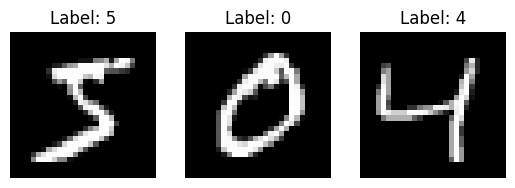

In [8]:
# Visualize some training images
for i in range(3):  
    plt.subplot(1, 3, 1 + i)
    plt.imshow(train_x[i], cmap=plt.get_cmap('gray'))
    plt.title(f"Label: {train_y[i]}")
    plt.axis('off')
plt.show()

In [9]:
# Create the directory if it does not exist
os.makedirs("data", exist_ok=True)

# Save the model in various formats
lenet_5_model.save('data/lenet_5_model.keras')
lenet_5_model.save("data/lenet_5_model.h5")

In [10]:
# Save the model architecture in JSON format
json_model = lenet_5_model.to_json()
with open('data/lenet_5_model.json', 'w') as json_file:
    json_file.write(json_model)

In [11]:
# Save the model weights in HDF5 format
lenet_5_model.save_weights('data/lenet_5_model.weights.h5')

In [12]:
# Model summary for inspection
lenet_5_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                          │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ S2 (AveragePooling2D)                │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ C3 (Conv2D)                          │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ S4 (AveragePooling2D)                │ (None, 5, 5, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ F5 (Dense)                           │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ F6 (Dense)                           │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ F7 (Dense)                           │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 185,120 (723.13 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 123,414 (482.09 KB)

In [13]:
# Extract and view the first layer weights
print(lenet_5_model.layers[0].get_weights()[0])  # Displays the weights of the first Conv2D layer (C1)


[[[[-5.19369692e-02 -3.02869976e-01 -8.23232085e-02  2.62462050e-01
     1.35934606e-01 -3.99292111e-02]]

  [[ 2.68882327e-02 -4.64022815e-01  5.12965173e-02  1.44741997e-01
     6.94972351e-02  1.77248389e-01]]

  [[ 1.12323672e-01 -2.71564722e-01  1.40303550e-02  4.22070861e-01
     9.38320756e-02 -3.26929539e-02]]

  [[ 3.02706212e-01  1.01892784e-01 -1.88660305e-02  3.95504475e-01
     2.14524016e-01  6.73409179e-02]]

  [[ 6.82032481e-02 -1.27566541e-02 -6.43509924e-02  2.28710532e-01
     1.04043156e-01  7.79910237e-02]]]


 [[[ 2.24712953e-01 -4.01097864e-01  5.95541112e-02 -1.01665072e-02
     1.19497210e-01  3.00103009e-01]]

  [[ 4.58100468e-01 -3.63560438e-01  3.44617248e-01  1.15961395e-02
     3.15363228e-01  3.36858630e-01]]

  [[ 6.84487760e-01 -2.10825920e-01  5.01375198e-01  2.42095485e-01
     8.93174484e-02  5.36520362e-01]]

  [[ 4.23970431e-01 -1.96735635e-02  5.29079318e-01  1.10611744e-01
     1.39534837e-02  4.66303498e-01]]

  [[-2.76309457e-02  3.54664922e-01

In [14]:
def save_model_weights_to_files(model, output_dir):
    """
    Extracts weights from a trained model and saves them to text files.

    Args:
        model: The trained TensorFlow/Keras model.
        output_dir: Directory where the weights will be saved.
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for layer in model.layers:
        weights = layer.get_weights()  # Get the weights and biases (if any) for the layer
        if weights:  # Some layers like ReLU or Dropout may not have weights
            weight_file = os.path.join(output_dir, f"{layer.name}_weights.txt")
            
            # Flatten weights for easier saving
            with open(weight_file, "w") as f:
                for weight_array in weights:
                    flat_weights = weight_array.flatten()
                    f.write(" ".join(map(str, flat_weights)))
                    f.write("\n")

            print(f"Saved weights for layer '{layer.name}' to {weight_file}")

# Save weights directly to files without including the layer name in each file
save_model_weights_to_files(lenet_5_model, "data")


Saved weights for layer 'C1' to data\C1_weights.txt
Saved weights for layer 'C3' to data\C3_weights.txt
Saved weights for layer 'F5' to data\F5_weights.txt
Saved weights for layer 'F6' to data\F6_weights.txt
Saved weights for layer 'F7' to data\F7_weights.txt
